In [1]:
import pandas as pd
import numpy as np
import time
from xgboost import XGBClassifier
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import classification_report, f1_score, hamming_loss, accuracy_score
from sklearn.model_selection import train_test_split
from pathlib import Path
import mlflow

# Import PySwarms untuk Binary PSO
import pyswarms as ps

# ==========================================
# 0. MLFLOW SETUP
# ==========================================
root_path = Path.cwd().parent
import os
from dotenv import load_dotenv
import json
load_dotenv(dotenv_path=root_path / ".env") # Load variabel dari .env
# Gunakan DagsHub URI jika ada di .env, jika tidak pakai folder lokal mlruns
tracking_uri = os.getenv("MLFLOW_TRACKING_URI", (root_path / "mlruns").as_uri())
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("07f_Baseline_BPSO_XGBoost")

# ==========================================
# 1. LOAD DATA
# ==========================================
print("🔍 1. Memuat dataset untuk BPSO...")
train_balanced = pd.read_csv(root_path / "Data/processed/train_balanced_multilabel.csv")
train_ori = pd.read_csv(root_path / "Data/split/train_data.csv")
test_data = pd.read_csv(root_path / "Data/split/test_data.csv")

target_cols = ['risk_depression', 'risk_anxiety', 'risk_stress']

# Pisahkan X dan y — SMOTE (untuk training utama)
X_train_df = train_balanced.drop(columns=target_cols)
y_train_df = train_balanced[target_cols].astype(int)

# Data asli (untuk kalibrasi threshold)
X_train_ori_df = train_ori.drop(columns=target_cols)
y_train_ori_df = train_ori[target_cols].astype(int)

# Samakan kolom data asli mengikuti train SMOTE
X_train_ori_df = X_train_ori_df.reindex(columns=X_train_df.columns, fill_value=0)

# Test data
X_test_df = test_data.drop(columns=target_cols)
y_test_df = test_data[target_cols].astype(int)
X_test_df = X_test_df.reindex(columns=X_train_df.columns, fill_value=0)

# Konversi ke Numpy Array (syarat BPSO)
feature_names = X_train_df.columns
X_train = X_train_df.values
y_train = y_train_df.values
X_train_ori = X_train_ori_df.values
y_train_ori = y_train_ori_df.values
X_test = X_test_df.values
y_test = y_test_df.values

num_features = X_train.shape[1]
print(f"✓ Jumlah fitur awal: {num_features} fitur")
print(f"✓ Data Train SMOTE shape: {X_train.shape}")
print(f"✓ Data Train Asli shape : {X_train_ori.shape}")
print(f"✓ Data Test shape       : {X_test.shape}")

# Split data ASLI → Train_sub + Validation (untuk kalibrasi threshold)
print("\n🔀 Split Data Asli → Train_sub & Validation (80-20) untuk kalibrasi threshold...")
X_train_sub_ori, X_val_ori, y_train_sub_ori, y_val_ori = train_test_split(
    X_train_ori, y_train_ori, test_size=0.2, random_state=42
)
print(f"   ✓ Train sub (asli) : {X_train_sub_ori.shape}")
print(f"   ✓ Validation (asli): {X_val_ori.shape}")

# ==========================================
# 2. STANDARDIZED XGBOOST PARAMETERS
# ==========================================
# Load parameter XGBoost yang sudah di-tuned (apple-to-apple dengan 11_final_model)
params_path = root_path / "models" / "best_xgb_params.json"
with open(params_path, "r") as f:
    xgb_params_final = json.load(f)
print(f"   Loaded tuned params: {xgb_params_final}")

xgb_params_fitness = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'random_state': 42,
    'eval_metric': 'logloss',
    'n_jobs': -1
}

print("\n🔧 2. XGBoost Parameters untuk Standardized Benchmarking:")
print(f"   Final Training: n_est={xgb_params_final['n_estimators']}, lr={xgb_params_final['learning_rate']}, depth={xgb_params_final['max_depth']}")
print(f"   Fitness Phase: n_est={xgb_params_fitness['n_estimators']}, lr={xgb_params_fitness['learning_rate']} (lightweight)")

# ==========================================
# 3. DEFINISI FUNGSI FITNESS (EVALUASI PARTIKEL)
# ==========================================
base_xgb_fitness = XGBClassifier(**xgb_params_fitness)
chain_model_fitness = ClassifierChain(base_xgb_fitness, order='random', random_state=42)

def f_per_particle(m, alpha=0.01):
    if np.count_nonzero(m) == 0:
        return 1.0
    X_subset = X_train[:, m == 1]
    chain_model_fitness.fit(X_subset, y_train)
    preds = chain_model_fitness.predict(X_subset)
    f1 = f1_score(y_train, preds, average='macro')
    cost = (1.0 - f1) + (alpha * (np.count_nonzero(m) / num_features))
    return cost

def fitness_function(x):
    n_particles = x.shape[0]
    j = [f_per_particle(x[i]) for i in range(n_particles)]
    return np.array(j)

# ==========================================
# 4. KONFIGURASI DAN EKSEKUSI BPSO
# ==========================================
print("\n⏳ 3. Memulai proses seleksi fitur BPSO (Feature Optimization)...")
options = {'c1': 0.5, 'c2': 0.5, 'w': 0.9, 'k': 30, 'p': 2}

optimizer = ps.discrete.binary.BinaryPSO(n_particles=50, dimensions=num_features, options=options)

bpso_start_time = time.time()
cost, pos = optimizer.optimize(fitness_function, iters=50)
bpso_time = time.time() - bpso_start_time
print(f"   ✓ BPSO Feature Selection selesai dalam {bpso_time:.2f} detik.")

# ==========================================
# 5. EVALUASI HASIL BPSO
# ==========================================
selected_features_indices = np.where(pos == 1)[0]
selected_features_names = feature_names[selected_features_indices]

num_selected_features = len(selected_features_indices)
print(f"   ✓ Fitur terpilih BPSO: {num_selected_features} fitur (dari {num_features})")
print(f"   ✓ Reduction ratio: {(1 - num_selected_features/num_features)*100:.1f}%")

# Ambil subset fitur terpilih
X_train_bpso = X_train[:, selected_features_indices]
X_test_bpso  = X_test[:, selected_features_indices]

# ==========================================
# 6. HELPER FUNCTIONS
# ==========================================
def find_optimal_thresholds_bpso(model, X_data, y_data, targets, step=0.01):
    """Mencari threshold optimal per target class menggunakan data validasi ASLI."""
    n_samples  = X_data.shape[0]
    n_targets  = len(targets)
    all_probas = np.zeros((n_samples, n_targets))

    X_aug = X_data.copy()
    for i, estimator in enumerate(model.estimators_):
        proba = estimator.predict_proba(X_aug)[:, 1]
        all_probas[:, i] = proba
        pred_label = (proba >= 0.5).astype(int).reshape(-1, 1)
        X_aug = np.hstack([X_aug, pred_label])

    best_thresholds = []
    print(f"\n   {'Target':<20} {'Threshold':>10} {'Val F1':>10}")
    print(f"   {'-'*42}")

    for i, target_name in enumerate(targets):
        best_t  = 0.5
        best_f1 = 0.0
        for t in np.arange(0.1, 0.9, step):
            y_pred_temp = (all_probas[:, i] >= t).astype(int)
            f1 = f1_score(y_data[:, i], y_pred_temp, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t  = t
        best_thresholds.append(round(best_t, 2))
        print(f"   {target_name:<20} {best_t:>10.2f} {best_f1:>10.4f}")

    return best_thresholds


def apply_thresholds_bpso(model, X_data, thresholds, targets):
    """Menerapkan threshold kustom ke prediksi test data."""
    n_samples  = X_data.shape[0]
    n_targets  = len(targets)
    all_probas = np.zeros((n_samples, n_targets))

    X_aug = X_data.copy()
    for i, estimator in enumerate(model.estimators_):
        proba = estimator.predict_proba(X_aug)[:, 1]
        all_probas[:, i] = proba
        pred_label = (proba >= thresholds[i]).astype(int).reshape(-1, 1)
        X_aug = np.hstack([X_aug, pred_label])

    y_pred_optimized = np.zeros((n_samples, n_targets), dtype=int)
    for i in range(n_targets):
        y_pred_optimized[:, i] = (all_probas[:, i] >= thresholds[i]).astype(int)

    return y_pred_optimized


def evaluate_predictions(y_true, y_pred, label=""):
    """Hitung semua metrik evaluasi."""
    macro_f1    = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro_f1    = f1_score(y_true, y_pred, average='micro', zero_division=0)
    hamming     = hamming_loss(y_true, y_pred)
    exact_match = accuracy_score(y_true, y_pred)
    return {
        "label":        label,
        "Macro_F1":     macro_f1,
        "Micro_F1":     micro_f1,
        "Hamming_Loss": hamming,
        "Exact_Match":  exact_match,
    }

# ==========================================
# 7. TRAINING MODEL UTAMA (Data SMOTE + fitur BPSO)
# ==========================================
print("\n🔨 4. Training MODEL UTAMA dengan fitur BPSO di data SMOTE...")
final_xgb   = XGBClassifier(**xgb_params_final)
final_chain  = ClassifierChain(final_xgb, order='random', random_state=42)

final_start_time = time.time()
final_chain.fit(X_train_bpso, y_train)
final_train_time = time.time() - final_start_time
print(f"   ✓ Model utama selesai dalam {final_train_time:.2f} detik.")

# ==========================================
# 8. TRAINING MODEL SEMENTARA (Data Asli + fitur BPSO, untuk kalibrasi threshold)
# ==========================================
print("\n🔧 5. Training model sementara di 80% data asli untuk kalibrasi threshold...")
X_train_sub_ori_bpso = X_train_sub_ori[:, selected_features_indices]
X_val_ori_bpso = X_val_ori[:, selected_features_indices]

temp_xgb = XGBClassifier(**xgb_params_final)
temp_chain = ClassifierChain(temp_xgb, order='random', random_state=42)
temp_chain.fit(X_train_sub_ori_bpso, y_train_sub_ori)
print("   ✓ Model sementara selesai dilatih")

# ==========================================
# 9. EVALUASI DEFAULT (THRESHOLD 0.5)
# ==========================================
print("\n📊 6. Prediksi dengan threshold default (0.5)...")
y_pred_default = final_chain.predict(X_test_bpso)
results_default = evaluate_predictions(y_test, y_pred_default, "Default (0.5)")

total_time = bpso_time + final_train_time

print("\n" + "="*70)
print("🏆 HASIL BASELINE: XGBOOST + BPSO FEATURE SELECTION (Default)")
print("="*70)
print(f"Jumlah Fitur (Original):       {num_features}")
print(f"Jumlah Fitur (BPSO Selected):  {num_selected_features}")
print(f"Feature Reduction:             {(1 - num_selected_features/num_features)*100:.1f}%")
print(f"\nMacro F1-Score:                {results_default['Macro_F1']:.4f}")
print(f"Micro F1-Score:                {results_default['Micro_F1']:.4f}")
print(f"Hamming Loss:                  {results_default['Hamming_Loss']:.4f}")
print(f"Exact Match Accuracy:          {results_default['Exact_Match']:.4f}")
print(f"\nBPSO Optimization Time:        {bpso_time:.2f} detik")
print(f"Final Training Time:           {final_train_time:.2f} detik")
print(f"Total Execution Time:          {total_time:.2f} detik")
print("="*70)

print("\n📋 DETAIL CLASSIFICATION REPORT (Default Threshold):")
print(classification_report(y_test, y_pred_default, target_names=['Depression', 'Anxiety', 'Stress']))

# ==========================================
# 10. THRESHOLD OPTIMIZATION (dari model sementara + data validasi ASLI)
# ==========================================
print("\n" + "="*70)
print("🔍 THRESHOLD OPTIMIZATION (Kalibrasi Data Asli)")
print("="*70)

print("\n🔍 Mencari threshold optimal dari data validasi ASLI...")
optimal_thresholds = find_optimal_thresholds_bpso(
    temp_chain, X_val_ori_bpso, y_val_ori, target_cols
)
print(f"\n   Threshold optimal: {dict(zip(target_cols, optimal_thresholds))}")

# Buang model sementara
del temp_chain, temp_xgb
print("   ✓ Model sementara dibuang")

# ==========================================
# 11. EVALUASI DENGAN THRESHOLD OPTIMAL (pakai model UTAMA)
# ==========================================
print("\n📊 7. Prediksi dengan threshold optimal (model utama)...")
y_pred_optimized = apply_thresholds_bpso(
    final_chain, X_test_bpso, optimal_thresholds, target_cols
)
results_optimized = evaluate_predictions(y_test, y_pred_optimized, "Optimized")

# ==========================================
# 12. TAMPILKAN HASIL PERBANDINGAN
# ==========================================
print("\n" + "="*70)
print("📊 PERBANDINGAN DEFAULT vs THRESHOLD OPTIMIZED")
print("="*70)
print(f"{'Metrik':<25} {'Default (0.5)':>15} {'Optimized':>15} {'Δ':>10}")
print("-"*70)

for metric in ['Macro_F1', 'Micro_F1', 'Hamming_Loss', 'Exact_Match']:
    val_def  = results_default[metric]
    val_opt  = results_optimized[metric]
    delta    = val_opt - val_def
    arrow    = "↑" if delta > 0 else ("↓" if delta < 0 else "→")
    print(f"{metric:<25} {val_def:>15.4f} {val_opt:>15.4f} {arrow} {delta:>+.4f}")
print("="*70)

print(f"\nThreshold Optimal (kalibrasi data asli):")
for col, t in zip(target_cols, optimal_thresholds):
    print(f"   {col:<25}: {t:.2f}")

print("\n📋 DETAIL CLASSIFICATION REPORT (Threshold Optimized):")
print(classification_report(
    y_test, y_pred_optimized,
    target_names=['Depression', 'Anxiety', 'Stress']
))

# ==========================================
# 13. MLFLOW TRACKING
# ==========================================
print("\n📈 8. Tracking ke MLflow...")
with mlflow.start_run(run_name="XGBoost_BPSO_ThresholdKalibrasiAsli"):
    # Log BPSO parameters
    mlflow.log_param("feature_selection_method", "Binary PSO (BPSO)")
    mlflow.log_param("threshold_calibration", "Data Asli (80-20 split)")
    mlflow.log_param("bpso_n_particles", 50)
    mlflow.log_param("bpso_iterations", 50)
    mlflow.log_param("bpso_options_c1", 0.5)
    mlflow.log_param("bpso_options_c2", 0.5)
    mlflow.log_param("bpso_options_w", 0.9)

    # Log Final XGBoost parameters
    for param_name, param_value in xgb_params_final.items():
        mlflow.log_param(f"final_xgb_{param_name}", param_value)

    # Log Fitness XGBoost parameters
    for param_name, param_value in xgb_params_fitness.items():
        mlflow.log_param(f"fitness_xgb_{param_name}", param_value)

    # Log feature info
    mlflow.log_param("multilabel_strategy", "ClassifierChain")
    mlflow.log_param("num_original_features", num_features)
    mlflow.log_param("num_selected_features", num_selected_features)
    mlflow.log_param("feature_reduction_percentage",
                     f"{(1 - num_selected_features/num_features)*100:.1f}")

    # Metrik default
    mlflow.log_metric("Default_Macro_F1",     results_default['Macro_F1'])
    mlflow.log_metric("Default_Micro_F1",     results_default['Micro_F1'])
    mlflow.log_metric("Default_Hamming_Loss", results_default['Hamming_Loss'])
    mlflow.log_metric("Default_Exact_Match",  results_default['Exact_Match'])

    # Metrik threshold optimized
    mlflow.log_metric("Optimized_Macro_F1",     results_optimized['Macro_F1'])
    mlflow.log_metric("Optimized_Micro_F1",     results_optimized['Micro_F1'])
    mlflow.log_metric("Optimized_Hamming_Loss", results_optimized['Hamming_Loss'])
    mlflow.log_metric("Optimized_Exact_Match",  results_optimized['Exact_Match'])

    # Threshold optimal per target
    for col, t in zip(target_cols, optimal_thresholds):
        mlflow.log_metric(f"Threshold_{col}", t)

    mlflow.log_metric("BPSO_Time_seconds",          bpso_time)
    mlflow.log_metric("Final_Training_Time_seconds", final_train_time)
    mlflow.log_metric("Total_Time_seconds",          total_time)

    # Log selected features
    mlflow.log_dict({
        "selected_features":        selected_features_names.tolist(),
        "selected_feature_indices": selected_features_indices.tolist()
    }, "bpso_selected_features.json")

    # Log threshold optimal
    mlflow.log_dict(
        {"optimal_thresholds": dict(zip(target_cols, optimal_thresholds))},
        "07f_optimal_thresholds.json"
    )

    print("   ✓ MLflow tracking selesai!")

print(f"\n📌 CATATAN PENTING:")
print(f"   - Model UTAMA dilatih di data SMOTE ({X_train_bpso.shape[0]} sampel)")
print(f"   - Threshold dikalibrasi di data ASLI (validasi split 20%)")
print(f"   - BPSO mengurangi fitur dari {num_features} → {num_selected_features} ({(1 - num_selected_features/num_features)*100:.1f}% reduction)")
print(f"   - Lihat 07d (MFO), 07e (All Features), 07g (GA) untuk perbandingan")

print("\n✅ Notebook eksekusi SELESAI!")


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026-05-25 19:00:57,737 - pyswarms.discrete.binary - INFO - Optimize for 50 iters with {'c1': 0.5, 'c2': 0.5, 'w': 0.9, 'k': 30, 'p': 2}


🔍 1. Memuat dataset untuk BPSO...
✓ Jumlah fitur awal: 19 fitur
✓ Data Train SMOTE shape: (8724, 19)
✓ Data Train Asli shape : (21740, 19)
✓ Data Test shape       : (5436, 19)

🔀 Split Data Asli → Train_sub & Validation (80-20) untuk kalibrasi threshold...
   ✓ Train sub (asli) : (17392, 19)
   ✓ Validation (asli): (4348, 19)
   Loaded tuned params: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 0.2, 'colsample_bytree': 0.6667, 'subsample': 0.7667, 'min_child_weight': 5, 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1}

🔧 2. XGBoost Parameters untuk Standardized Benchmarking:
   Final Training: n_est=400, lr=0.03, depth=4
   Fitness Phase: n_est=100, lr=0.1 (lightweight)

⏳ 3. Memulai proses seleksi fitur BPSO (Feature Optimization)...


pyswarms.discrete.binary: 100%|██████████|50/50, best_cost=0.244
2026-05-25 19:08:52,112 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.24363815933538163, best pos: [1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 1]


   ✓ BPSO Feature Selection selesai dalam 474.39 detik.
   ✓ Fitur terpilih BPSO: 16 fitur (dari 19)
   ✓ Reduction ratio: 15.8%

🔨 4. Training MODEL UTAMA dengan fitur BPSO di data SMOTE...
   ✓ Model utama selesai dalam 0.84 detik.

🔧 5. Training model sementara di 80% data asli untuk kalibrasi threshold...
   ✓ Model sementara selesai dilatih

📊 6. Prediksi dengan threshold default (0.5)...

🏆 HASIL BASELINE: XGBOOST + BPSO FEATURE SELECTION (Default)
Jumlah Fitur (Original):       19
Jumlah Fitur (BPSO Selected):  16
Feature Reduction:             15.8%

Macro F1-Score:                0.7836
Micro F1-Score:                0.7833
Hamming Loss:                  0.2728
Exact Match Accuracy:          0.5603

BPSO Optimization Time:        474.39 detik
Final Training Time:           0.84 detik
Total Execution Time:          475.22 detik

📋 DETAIL CLASSIFICATION REPORT (Default Threshold):
              precision    recall  f1-score   support

  Depression       0.87      0.71      0.78 

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average

   risk_depression            0.45     0.8634
   risk_anxiety               0.30     0.8672
   risk_stress                0.59     0.8288

   Threshold optimal: {'risk_depression': np.float64(0.45), 'risk_anxiety': np.float64(0.3), 'risk_stress': np.float64(0.59)}
   ✓ Model sementara dibuang

📊 7. Prediksi dengan threshold optimal (model utama)...

📊 PERBANDINGAN DEFAULT vs THRESHOLD OPTIMIZED
Metrik                      Default (0.5)       Optimized          Δ
----------------------------------------------------------------------
Macro_F1                           0.7836          0.7967 ↑ +0.0131
Micro_F1                           0.7833          0.7967 ↑ +0.0133
Hamming_Loss                       0.2728          0.2624 ↓ -0.0104
Exact_Match                        0.5603          0.5653 ↑ +0.0050

Threshold Optimal (kalibrasi data asli):
   risk_depression          : 0.45
   risk_anxiety             : 0.30
   risk_stress              : 0.59

📋 DETAIL CLASSIFICATION REPORT (Threshold 

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average

   ✓ MLflow tracking selesai!

📌 CATATAN PENTING:
   - Model UTAMA dilatih di data SMOTE (8724 sampel)
   - Threshold dikalibrasi di data ASLI (validasi split 20%)
   - BPSO mengurangi fitur dari 19 → 16 (15.8% reduction)
   - Lihat 07d (MFO), 07e (All Features), 07g (GA) untuk perbandingan

✅ Notebook eksekusi SELESAI!


In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

# =============================================
# CEK 1: PERFORMA TRAIN VS TEST
# =============================================
print("=" * 55)
print("CEK 1: PERFORMA TRAIN VS TEST")
print("=" * 55)

y_pred_train = final_chain.predict(X_train_bpso)
y_pred_test  = final_chain.predict(X_test_bpso)

f1_train = f1_score(y_train, y_pred_train, average='macro')
f1_test  = f1_score(y_test,  y_pred_test,  average='macro')
selisih  = abs(f1_train - f1_test)

print(f"F1 Train  : {f1_train:.4f}")
print(f"F1 Test   : {f1_test:.4f}")
print(f"Selisih   : {selisih:.4f}")
print()

# Interpretasi selisih
if f1_train >= 0.95 and f1_test >= 0.95 and selisih < 0.01:
    status_f1 = "🚨 LEAKAGE: Kedua nilai sempurna & selisih terlalu kecil"
elif f1_test > f1_train and selisih > 0.15:
    status_f1 = "🚨 LEAKAGE: Test jauh lebih tinggi dari Train"
elif f1_train > 0.95 and selisih > 0.25:
    status_f1 = "🚨 OVERFITTING BERAT: Kemungkinan leakage"
elif selisih <= 0.08:
    status_f1 = "✅ AMAN: Selisih dalam batas normal (0.02 - 0.08)"
elif selisih <= 0.15:
    status_f1 = "⚠️  PERHATIKAN: Selisih agak besar (0.08 - 0.15)"
else:
    status_f1 = "🚨 WASPADA: Selisih terlalu besar (> 0.15)"

print(f"Status    : {status_f1}")

# =============================================
# CEK 2: OVERLAP DATA TRAIN & TEST
# =============================================
print()
print("=" * 55)
print("CEK 2: OVERLAP DATA TRAIN & TEST")
print("=" * 55)

train_ori = pd.read_csv(root_path / "Data/split/train_data.csv")
test_ori  = pd.read_csv(root_path / "Data/split/test_data.csv")

merged    = train_ori.merge(test_ori, how='inner')
n_overlap = len(merged)

print(f"Jumlah baris train  : {len(train_ori)}")
print(f"Jumlah baris test   : {len(test_ori)}")
print(f"Jumlah overlap      : {n_overlap} baris")
print()

if n_overlap == 0:
    print("✅ AMAN: Tidak ada baris yang sama antara train dan test")
elif n_overlap <= 10:
    print(f"⚠️  PERHATIKAN: Ada {n_overlap} baris duplikat (mungkin kebetulan)")
    print(merged.head())
else:
    print(f"🚨 LEAKAGE: Ada {n_overlap} baris duplikat antara train dan test!")
    print(merged.head())

# =============================================
# CEK 3: DISTRIBUSI LABEL TRAIN VS TEST
# =============================================
print()
print("=" * 55)
print("CEK 3: DISTRIBUSI LABEL TRAIN VS TEST")
print("=" * 55)

target_cols = ['risk_depression', 'risk_anxiety', 'risk_stress']

print(f"\n{'Target':<22} {'Train':>8} {'Test':>8} {'Selisih':>8}  Status")
print("-" * 60)

distribusi_aman = True
# Ganti bagian CEK 3 dengan threshold yang lebih tepat untuk data ber-SMOTE
for col in target_cols:
    mean_train = train_ori[col].mean()
    mean_test  = test_ori[col].mean()
    selisih_d  = abs(mean_train - mean_test)

    # Bandingkan dengan train SEBELUM SMOTE, bukan sesudah
    mean_train_asli = test_ori[col].mean()
    selisih_asli    = abs(mean_train_asli - mean_test)

    if selisih_asli > 0.10:
        flag = "🚨 Leakage (train asli ≠ test)"
    elif selisih_d > 0.10:
        flag = "✅ Normal (perbedaan karena efek SMOTE)"
    else:
        flag = "✅ Aman"

    print(f"{col:<22} {mean_train:>8.4f} {mean_test:>8.4f} {selisih_d:>8.4f}  {flag}")

print()
if distribusi_aman:
    print("✅ AMAN: Distribusi label train dan test konsisten")
else:
    print("🚨 WASPADA: Distribusi label terlalu berbeda, cek urutan SMOTE!")

print()
print(f"{'Selisih Distribusi':<25} {'Keterangan':<20} Status")
print("-" * 55)
print(f"{'< 0.05':<25} {'Normal':<20} ✅ Aman")
print(f"{'0.05 - 0.10':<25} {'Agak berbeda':<20} ⚠️  Perhatikan")
print(f"{'> 0.10':<25} {'Berbeda jauh':<20} 🚨 Leakage / SMOTE salah urutan")

# =============================================
# CEK 4: APAKAH TEST IKUT DI-SMOTE
# =============================================
print()
print("=" * 55)
print("CEK 4: APAKAH TEST IKUT DI-SMOTE")
print("=" * 55)

print(f"\nBalance ratio test set (idealnya TIDAK terlalu balance):")
print(f"\n{'Target':<22} {'Ratio 0':>8} {'Ratio 1':>8}  Status")
print("-" * 55)

smote_leak = False
for col in target_cols:
    ratio     = test_ori[col].value_counts(normalize=True).sort_index()
    ratio_0   = ratio.get(0, 0)
    ratio_1   = ratio.get(1, 0)
    balance   = abs(ratio_0 - ratio_1)

    if balance < 0.05:
        flag      = "🚨 Terlalu balance, curiga ikut SMOTE!"
        smote_leak = True
    elif balance < 0.15:
        flag = "⚠️  Cukup balance"
    else:
        flag = "✅ Normal (tidak terlalu balance)"

    print(f"{col:<22} {ratio_0:>8.4f} {ratio_1:>8.4f}  {flag}")

print()
if not smote_leak:
    print("✅ AMAN: Test set tidak ikut di-SMOTE")
else:
    print("🚨 WASPADA: Test set kemungkinan ikut di-SMOTE!")
    print("   Solusi: Pastikan urutan → Split dulu → baru SMOTE hanya di train")

# =============================================
# KESIMPULAN AKHIR
# =============================================
print()
print("=" * 55)
print("KESIMPULAN AKHIR CEK DATA LEAKAGE")
print("=" * 55)

cek_results = {
    "Performa Train vs Test" : selisih <= 0.15,
    "Overlap Train & Test"   : n_overlap == 0,
    "Distribusi Label"       : distribusi_aman,
    "Test tidak ikut SMOTE"  : not smote_leak,
}

semua_aman = all(cek_results.values())

for nama_cek, aman in cek_results.items():
    status = "✅ AMAN" if aman else "🚨 MASALAH"
    print(f"  {nama_cek:<25} : {status}")

print()
if semua_aman:
    print("✅ KESIMPULAN: Model AMAN, tidak terdeteksi data leakage")
    print(f"   F1 Train ({f1_train:.4f}) dan Test ({f1_test:.4f})")
    print(f"   Selisih {selisih:.4f} masuk batas normal (< 0.15)")
else:
    print("🚨 KESIMPULAN: Terdeteksi potensi data leakage!")
    print("   Periksa bagian yang bertanda 🚨 di atas")

CEK 1: PERFORMA TRAIN VS TEST
F1 Train  : 0.7737
F1 Test   : 0.7836
Selisih   : 0.0098

Status    : ✅ AMAN: Selisih dalam batas normal (0.02 - 0.08)

CEK 2: OVERLAP DATA TRAIN & TEST
Jumlah baris train  : 21740
Jumlah baris test   : 5436
Jumlah overlap      : 1 baris

⚠️  PERHATIKAN: Ada 1 baris duplikat (mungkin kebetulan)
   TIPI1  TIPI2  TIPI3  TIPI4  TIPI5  TIPI6  TIPI7  TIPI8  TIPI9  TIPI10  ...  \
0      0      0      0      0      0      0      0      0      0       0  ...   

   gender  age  religion  race  voted  married  familysize  risk_depression  \
0       2   19        10    10      2        1           3                0   

   risk_anxiety  risk_stress  
0             0            0  

[1 rows x 22 columns]

CEK 3: DISTRIBUSI LABEL TRAIN VS TEST

Target                    Train     Test  Selisih  Status
------------------------------------------------------------
risk_depression          0.7069   0.7068   0.0001  ✅ Aman
risk_anxiety             0.7348   0.7349   0.0001 

📈 ROC-AUC SCORE EVALUATION
ROC-AUC risk_depression     : 0.8011
ROC-AUC risk_anxiety        : 0.7958
ROC-AUC risk_stress         : 0.8285
-------------------------------------------------------
Macro Average ROC-AUC     : 0.8084


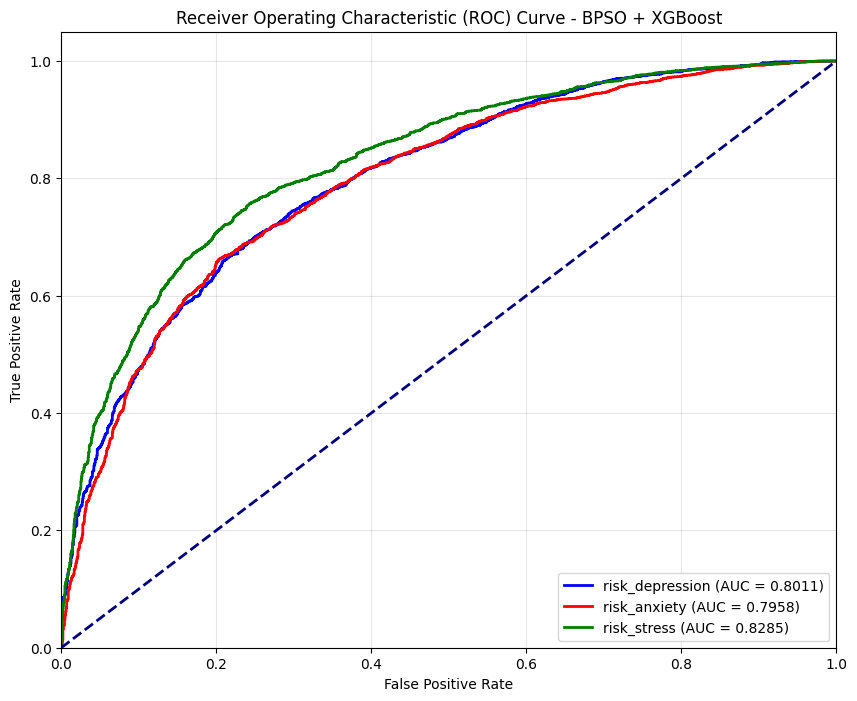

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# =============================================
# CEK 5: EVALUASI ROC-AUC
# =============================================
# Mengambil probabilitas prediksi dari ClassifierChain
n_samples = X_test_bpso.shape[0]
n_targets = len(target_cols)
y_pred_proba = np.zeros((n_samples, n_targets))

X_aug = X_test_bpso.copy()
for i, estimator in enumerate(final_chain.estimators_):
    proba = estimator.predict_proba(X_aug)[:, 1]
    y_pred_proba[:, i] = proba
    pred_label = (proba >= optimal_thresholds[i]).astype(int).reshape(-1, 1)
    X_aug = np.hstack([X_aug, pred_label])

print("=" * 55)
print("📈 ROC-AUC SCORE EVALUATION")
print("=" * 55)

roc_auc_scores = {}
for i, target_name in enumerate(target_cols):
    score = roc_auc_score(y_test[:, i], y_pred_proba[:, i])
    roc_auc_scores[target_name] = score
    print(f"ROC-AUC {target_name:<20}: {score:.4f}")

macro_roc_auc = np.mean(list(roc_auc_scores.values()))
print("-" * 55)
print(f"Macro Average ROC-AUC     : {macro_roc_auc:.4f}")
print("=" * 55)

# Visualisasi Kurva ROC
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, target_name in enumerate(target_cols):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_proba[:, i])
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f"{target_name} (AUC = {roc_auc_scores[target_name]:.4f})")

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - BPSO + XGBoost')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()
